Linear Fit
MSE: 372.0051625579934
R2: 0.05555558712253694

Cubic Polynomial Fit
MSE: 107.11173673839265
R2: 0.7280653832313249

Polynomial is better fit


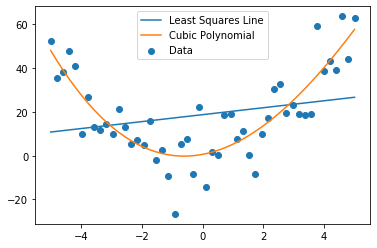

Degree 1
MSE: 372.0051625579934
R2: 0.05555558712253694



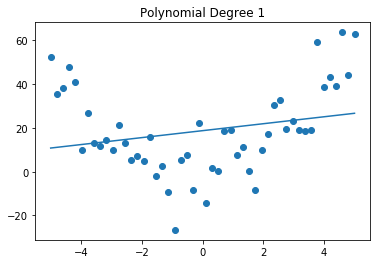

Degree 2
MSE: 108.8859685268728
R2: 0.7235609745068399



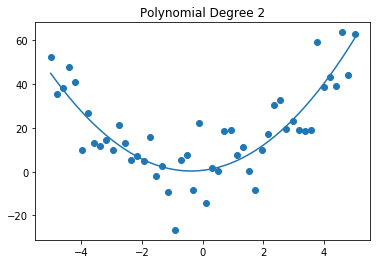

Degree 3
MSE: 107.11173673839265
R2: 0.7280653832313249



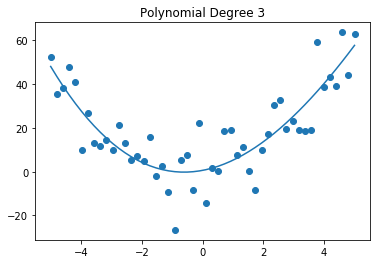

Degree 4
MSE: 106.64598775650336
R2: 0.7292478238746859



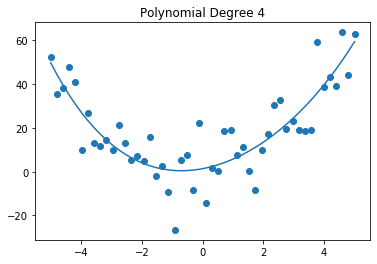

Degree 5
MSE: 106.56131173306981
R2: 0.7294627988408573



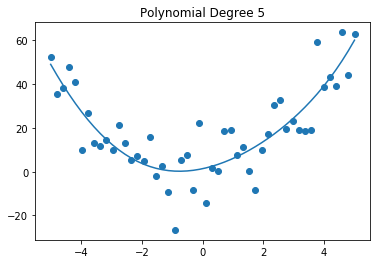

Degree 6
MSE: 106.50809238892032
R2: 0.7295979117836278



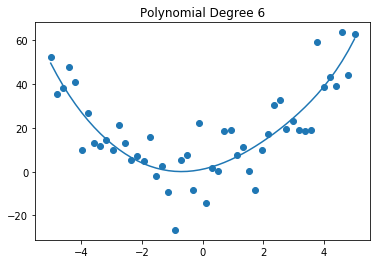

Degree 10
MSE: 103.47182852225643
R2: 0.7373063597663768



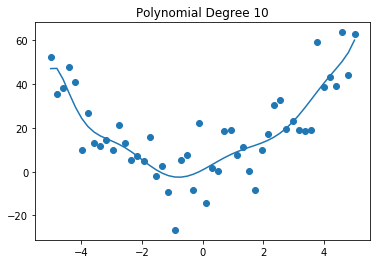

Degree 15
MSE: 86.17010765722253
R2: 0.78123186201421



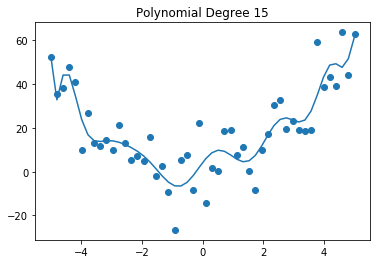

Vandermonde Polynomial Fit
MSE: 107.11173673839266
R2: 0.7280653832313249


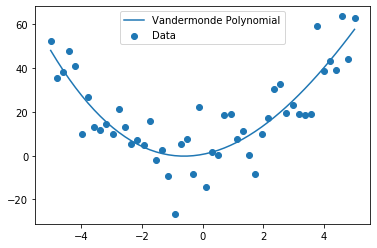

In [1]:
# Part A 
import numpy as np 
import matplotlib.pyplot as plt 

get_ipython().run_line_magic('matplotlib', 'inline') 

np.random.seed(0) 
x = np.linspace(-5,5,50) 
y = 2*x**2 + 3*x + np.random.randn(50)*10 

A = np.vstack([x, np.ones(len(x))]).T 
m,c = np.linalg.lstsq(A,y,rcond=None)[0] 

y_linear = m*x + c 
degree = 3 
coefficients = np.polyfit(x,y,degree)
polynomial = np.poly1d(coefficients) 
y_poly = polynomial(x) 

def evaluate(y_true,y_pred):     
    mse = np.mean((y_true - y_pred)**2)     
    ss_total = np.sum((y_true - np.mean(y_true))**2)     
    ss_res = np.sum((y_true - y_pred)**2)     
    r2 = 1 - (ss_res/ss_total)     
    return mse,r2

mse_linear,r2_linear = evaluate(y,y_linear)
mse_poly,r2_poly = evaluate(y,y_poly) 

print("Linear Fit") 
print("MSE:",mse_linear) 
print("R2:",r2_linear) 
print("\nCubic Polynomial Fit") 
print("MSE:",mse_poly) 
print("R2:",r2_poly) 

# Decide better model 
if mse_poly < mse_linear:    
    print("\nPolynomial is better fit") 
else: print("\nLinear model is better fit") 

plt.scatter(x,y,label="Data") 
plt.plot(x,y_linear,label="Least Squares Line") 
plt.plot(x,y_poly,label="Cubic Polynomial") 
plt.legend() 
plt.show() 

degrees = [1,2,3,4,5,6,10,15] 
results = [] 

for degree in degrees:     
        coefficients = np.polyfit(x,y,degree)     
        polynomial = np.poly1d(coefficients)    
        y_pred = polynomial(x)     
        mse = np.mean((y - y_pred)**2)     
        ss_total = np.sum((y - np.mean(y))**2)     
        ss_res = np.sum((y - y_pred)**2)     
        r2 = 1 - (ss_res/ss_total)     
        results.append((degree,mse,r2))     
        
        print(f"Degree {degree}")     
        print("MSE:",mse)     
        print("R2:",r2)     
        print()     
        plt.figure()    
        plt.scatter(x,y)     
        plt.plot(x,y_pred)     
        plt.title(f"Polynomial Degree {degree}")    
        plt.show()
        
# Part C 
degree = 3 
V = np.vander(x, N=degree+1, increasing=True) 
VT_V = np.dot(V.T,V) 
VT_y = np.dot(V.T,y)
    
coefficients = np.linalg.solve(VT_V,VT_y) 
       
# matrix multiplication
y_vander = V @ coefficients 
    
mse_vander = np.mean((y - y_vander)**2)
ss_total = np.sum((y - np.mean(y))**2) 
ss_res = np.sum((y - y_vander)**2) 
r2_vander = 1 - (ss_res/ss_total) 
        
print("Vandermonde Polynomial Fit") 
print("MSE:",mse_vander) 
print("R2:",r2_vander) 
plt.scatter(x,y,label="Data")
plt.plot(x,y_vander,label="Vandermonde Polynomial") 
plt.legend()
plt.show()